In [5]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

sys.path.append('..')
from utils import makefolder

rcpsize = 20
plt.rcParams['xtick.labelsize'] = rcpsize
plt.rcParams['ytick.labelsize'] = rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)


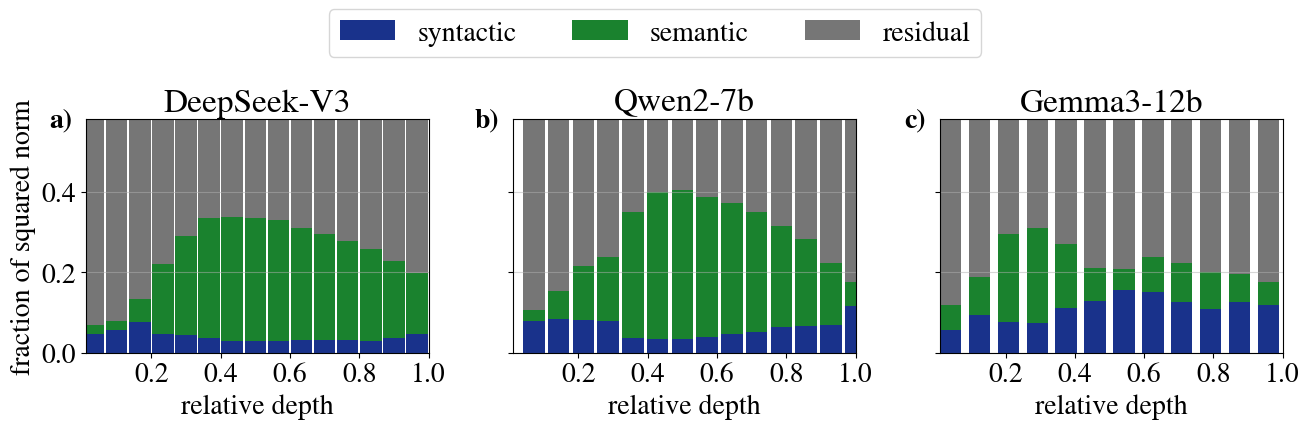

In [8]:
models = ['deepseek', 'qwen7b', 'gemma12b']
display_titles = {'deepseek': 'DeepSeek-V3', 'qwen7b': 'Qwen2-7b', 'gemma12b': 'Gemma3-12b'}
panel_labels = ['a)', 'b)', 'c)']
avg_tokens = 0
min_token_length = 3
n_tokens = 1
global_center_flag = 1

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True)

for i, model_name in enumerate(models):
    ax = axes[i]
    resultsfolder = makefolder(
        base='../results/norms/syn-sem/',
        model_name=model_name,
        avg_tokens=avg_tokens,
        min_token_length=min_token_length,
        n_tokens=n_tokens,
        global_center_flag=global_center_flag,
    )
    npz_path = os.path.join(resultsfolder, 'norms.npz')
    data = np.load(npz_path)

    rel_depths = data['rel_depths']
    syn_means = data['syn_means']
    sem_means = data['sem_means']
    residual_means = data['residual_means']

    bar_width = 0.062
    n_layers = len(rel_depths)
    x = np.linspace(1 / n_layers, 1, n_layers)

    if model_name != 'qwen7b':
        idx = np.arange(n_layers)
        mask = (idx % 2 == 0)
        x = x[mask]
        syn_means = syn_means[mask]
        sem_means = sem_means[mask]
        residual_means = residual_means[mask]

    ax.bar(x, syn_means, width=bar_width, label='syntactic', alpha=0.9)
    ax.bar(x, sem_means, width=bar_width, bottom=syn_means, label='semantic', alpha=0.9)
    ax.bar(
        x,
        residual_means,
        width=bar_width,
        bottom=syn_means + sem_means,
        label='residual',
        alpha=0.9,
        color='#676767',
    )

    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_xticklabels([f'{t:.1f}' for t in np.linspace(0, 1, 6)])
    ax.set_xlabel('relative depth', fontsize=rcpsize)
    ax.set_xlim(0.01, 1.0)
    ax.set_ylim(0, 0.58)
    ax.grid(True, axis='y', alpha=0.5)
    ax.set_title(display_titles[model_name])
    ax.text(-0.04, 1.05, panel_labels[i], transform=ax.transAxes, fontsize=rcpsize, fontweight='bold', va='top', ha='right')

axes[0].set_ylabel('fraction of squared norm', fontsize=rcpsize)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout(rect=[0, 0, 1, 0.93])

figs_folder = '../results/figs/norms/n_tokens_1/'
os.makedirs(figs_folder, exist_ok=True)
fig.savefig(os.path.join(figs_folder, 'last_token_norms_three_models.pdf'), bbox_inches='tight')
plt.show()
